# 04 · Estudo do modelo de especialização (MLP Regressor) e importância das features
**Grupo 4 · base do Grupo 1 (Daily Delhi Climate)**

## 1. Funcionamento e intuição
Um **perceptron multicamadas (MLP) para regressão** aproxima uma função y = f(x) compondo transformações afins com **não linearidades**. Com uma camada oculta de *h* neurônios:

**ŷ = w₂ᵀ · σ(W₁ x + b₁) + b₂**

Cada neurônio oculto calcula uma combinação linear das features e passa o resultado por uma ativação σ (ReLU: max(0, z); tanh: saturante em ±1); a saída é uma combinação linear desses neurônios.
Intuição: sem σ o modelo seria uma regressão linear; com σ, a rede dobra e combina "pedaços" lineares e consegue representar relações **não lineares e interações** entre features
(por exemplo, "o efeito do vento depende do nível de umidade"). O **treino** ajusta W e b minimizando o erro quadrático mais uma penalidade L2 (no `sklearn`, o termo é **α/(2n)·‖W‖²**), por **retropropagação** do gradiente.
Os otimizadores usados aqui são o **L-BFGS** (quase-Newton, adequado a conjuntos pequenos) e o **Adam** (gradiente estocástico com taxas adaptativas).

## 2. Hipóteses, vantagens, limitações e preparação dos dados
| Aspecto | Descrição |
|---|---|
| Hipótese principal | O alvo é uma função razoavelmente **suave** das features; amostras de treino representam a região onde se prevê |
| Vantagens | Captura não linearidades e interações; não exige especificar a forma funcional; trata muitas features correlacionadas (com regularização) |
| Limitações | **Pouco dado** (aqui ≈ 78 amostras de treino por origem) leva a sobreajuste; **sensível à inicialização** (mínimos locais) e à escala; **extrapola mal** fora da faixa vista; pouco interpretável; muitos hiperparâmetros |
| Específico de séries temporais | Não tem noção de tempo: a ordem entra só pelas features (lags, médias, calendário). As amostras são **dependentes**, então a validação precisa ser **walk-forward** (não *k-fold* aleatório) |
| Preparação exigida | **Padronizar** as features e o alvo (média 0, desvio 1) **ajustando só no treino** de cada origem; mesmas features do Random Forest; alvo em Δ (y(t+1) − y(t)) para lidar com a tendência |
| Ruído de inicialização | Média de **5 sementes** no teste (3 na busca), registrando a dispersão entre sementes |

## 3. Papel dos principais hiperparâmetros
| Hiperparâmetro | Papel | Efeito esperado | Faixa testada |
|---|---|---|---|
| `hidden_layer_sizes` | capacidade (nº de neurônios/camadas) | mais neurônios → mais flexível e mais risco de sobreajuste | (16), (32), (64), (32,16) |
| `activation` | forma da não linearidade | ReLU: linear por partes; tanh: suave e limitada | relu, tanh |
| `alpha` (L2) | força da regularização | alto → pesos pequenos, função mais suave, modelo mais próximo da "previsão nula" (aqui: Δ=0, ou seja, **persistência**) | 1e-3 a 10 |
| `solver` / `learning_rate_init` | algoritmo e passo do otimizador | passo grande → instabilidade; pequeno → lento | lbfgs, adam; 1e-3, 1e-2 |
| `max_iter` | nº máximo de iterações | pouco → subajuste; muito → custo (sem *early stopping*, ver limitações) | 500 (lbfgs), 300 (adam), fixos |
| `w` (janela) | quantos lags a rede enxerga | janela maior → mais features, mais risco de sobreajuste | 3, 7, 14 |
| alvo (nível/Δ) | o que a rede aprende | Δ remove a tendência e a torna menos dependente de extrapolar | nível, Δ |

In [1]:
import sys, json, warnings
sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import trabalhoseries_redeneural.src.tsutils_delhi as tu
import trabalhoseries_redeneural.src.plots_delhi as pl
import trabalhoseries_redeneural.src.pipeline_delhi as pp
warnings.filterwarnings('ignore')
R = '../results/'
sel = json.load(open(R + 'hiperparametros_selecionados.json')); m = sel['MLP Regressor']
display(pd.Series(m, name='valor').to_frame())
print('Random Forest usa a MESMA janela w =', sel['Random Forest']['w'], '=> mesmas', pp.feature_frame(m['w']).shape[1], 'features.')

Random Forest usa a MESMA janela w = 14 => mesmas 30 features.


,valor
w,14
hidden,[32]
activation,relu
alpha,10
solver,lbfgs
lr,0.01
target,delta


## 4. Método de otimização adotado
Busca **aleatória reprodutível** (60 configurações de 1.152; semente 42) com critério de **MAE do walk-forward interno** (14 origens, reajuste a cada origem, 3 sementes promediadas), sem uso do teste.
O resultado e a análise dos efeitos estão no notebook 02 (seções 3 e 3.2). Em resumo: **alvo em Δ** e **α alto (10)** foram os efeitos mais claros; ativação e solver foram irrelevantes.

## 5. Arquitetura final e relação parâmetros × amostras

In [2]:
X = pp.feature_frame(m['w']); ntr = pp.TEST_ROWS[0]
mdl = pp.MLPModel(tuple(m['hidden']), m['activation'], m['alpha'], m['solver'], m['lr'], 1).fit(
        X.iloc[:ntr].values, pp.Y_LEVEL.values[:ntr] - pp.Y_CUR.values[:ntr])
net = mdl.models[0]
n_par = sum(w.size for w in net.coefs_) + sum(b.size for b in net.intercepts_)
print(f'entradas = {X.shape[1]} | camadas ocultas = {m["hidden"]} | ativação = {m["activation"]} | saída = 1')
print(f'parâmetros treináveis = {n_par} | amostras de treino (origens) = {ntr} | razão parâmetros/amostras = {n_par/ntr:.1f}')
print(f'iterações do otimizador = {net.n_iter_} | erro final de treino (escala padronizada) = {net.loss_:.4f}')
print('norma L2 dos pesos da 1ª camada: %.3f' % np.linalg.norm(net.coefs_[0]))

entradas = 30 | camadas ocultas = [32] | ativação = relu | saída = 1
parâmetros treináveis = 1025 | amostras de treino (origens) = 78 | razão parâmetros/amostras = 13.1
iterações do otimizador = 500 | erro final de treino (escala padronizada) = 0.4015
norma L2 dos pesos da 1ª camada: 0.954


**Leitura.** A rede tem **cerca de 13 vezes mais parâmetros do que amostras**: sem regularização ela memorizaria o treino. É por isso que o α alto é selecionado e é coerente com a hipótese "poucos dados".
O custo é que, com L2 forte, a previsão de Δ é puxada para perto de zero, ou seja, o MLP **tende à persistência**, o que ajuda a explicar o MAE do MLP ficar muito próximo ao dela.

## 6. Curva de aprendizado (diagnóstico com Adam)
Treino apenas nas origens anteriores à validação interna; erro medido na validação interna (região de treino; o teste não é usado).

menor MAE de validação: 1.414 na época 6 | MAE de treino nessa época: 1.988
final (época 300): treino = 1.162 | validação = 1.539


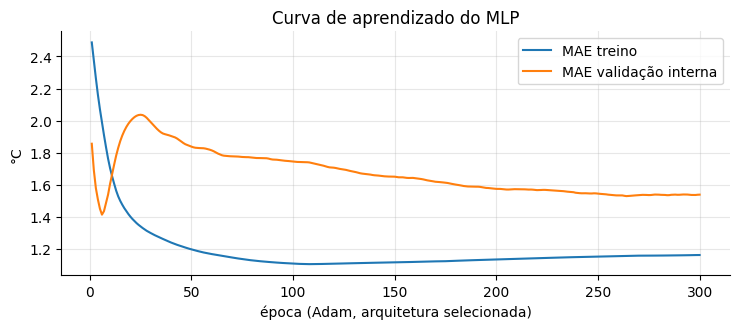

In [3]:
curve = pd.read_csv(R + 'mlp_curva_aprendizado.csv')
pl.mlp_curve(curve)
b = curve.loc[curve.MAE_validacao_interna.idxmin()]
print(f'menor MAE de validação: {b.MAE_validacao_interna:.3f} na época {int(b.epoca)} | MAE de treino nessa época: {b.MAE_treino:.3f}')
print(f'final (época 300): treino = {curve.MAE_treino.iloc[-1]:.3f} | validação = {curve.MAE_validacao_interna.iloc[-1]:.3f}')

**Leitura.** O erro de treino cai de ≈ 2,0 para ≈ 1,2 °C. O **melhor** MAE de validação interna (≈ 1,41) ocorre **cedo** (época 6); depois a validação piora levemente (≈ 1,54 na época 300) enquanto o treino continua caindo: sinal de **sobreajuste** e de que mais épocas não trazem ganho de generalização, comportamento típico de **pouca informação preditiva e pouco dado**.
(A configuração final usa L-BFGS; esta curva com Adam serve para diagnosticar o regime de aprendizado, não é o modelo avaliado.)
**Limitação reconhecida:** não foi usado *early stopping* com validação própria, porque com ~80 amostras separar um bloco extra de validação deixaria o treino ainda menor; a regularização L2 e o número fixo de iterações cumprem esse papel.

## 7. Sensibilidade à inicialização (sementes) e ao α

In [4]:
sd = pd.read_csv(R + 'mlp_sensibilidade_semente.csv')
P = pd.read_csv(R + 'previsoes_walkforward.csv')
print('MAE no teste por semente (cada uma é um walk-forward completo com 22 reajustes):'); display(sd.round(3))
print(f'média das sementes = {sd.MAE_teste.mean():.3f} | desvio = {sd.MAE_teste.std():.3f} | min-máx = {sd.MAE_teste.min():.3f}-{sd.MAE_teste.max():.3f}')
print(f'MAE do conjunto (média das previsões das 5 sementes) = {tu.mae(P.real, P["MLP Regressor"]):.3f}')
al = pd.read_csv(R + 'mlp_sensibilidade_alpha_posthoc.csv'); display(al.round(3))

MAE no teste por semente (cada uma é um walk-forward completo com 22 reajustes):
média das sementes = 1.106 | desvio = 0.010 | min-máx = 1.089-1.113
MAE do conjunto (média das previsões das 5 sementes) = 1.104


,semente,MAE_teste
0,0,1.113
1,1,1.107
2,2,1.113
3,3,1.106
4,4,1.089


,alpha,MAE_validacao_interna,MAE_teste_posthoc
0,1,1.456,1.297
1,3,1.423,1.221
2,10,1.229,1.109
3,30,1.376,1.074
4,100,1.291,1.048


**Leitura.** A dispersão entre sementes é **pequena** (da ordem de 0,01-0,02 °C), muito menor do que as diferenças entre modelos que importam e do que o erro de amostragem do teste; o resultado do MLP **não depende da semente**.
A tabela de α é **pós-hoc** (usa o teste só para descrever; **não alterou a seleção**): a validação interna prefere α=10, enquanto o teste melhora monotonicamente com α maior (1,30 → 1,05), chegando ao nível da persistência (1,06).
Isso reforça a leitura de que **"mais regularização = mais próximo da persistência"** e de que **não há ganho demonstrado** do MLP sobre ela nesta base.

## 8. Ablação por grupo de features (diagnóstico, não usada para selecionar)
Retreinamento walk-forward do MLP final removendo um grupo de features por vez (3 sementes).

In [5]:
ab = pd.read_csv(R + 'mlp_ablacao.csv'); display(ab.round(3))

,configuracao,MAE_teste
0,completo,1.109
1,sem umidade,1.111
2,sem vento,1.072
3,sem pressão,1.127
4,sem calendário (sen/cos anual),1.08


**Leitura.** Todas as ablações ficam entre ≈ 1,07 e ≈ 1,13 °C, **dentro do ruído**: retirar o vento ou o calendário até reduz levemente o MAE (≈ −0,03 a −0,04), retirar a pressão o aumenta (≈ +0,02).
Dado o tamanho do teste e o fato de os erros serem dominados por um choque comum (notebook 03), **nenhuma dessas diferenças é conclusiva**. Importante: **o modelo não foi reescolhido com base nesta tabela** (seria vazamento do teste).

## 9. Importância das features
**Método.** *Permutation Importance* (compatível com RF e MLP): embaralha-se uma feature (ou um grupo) no conjunto de teste e mede-se o **aumento do MAE** (100 repetições, semente fixa).
Para o RF, mostra-se também a importância nativa por impureza (MDI), conhecida por favorecer variáveis contínuas e correlacionadas.
O modelo avaliado aqui é o **ajustado uma única vez em todo o treino** (sem reajuste ao longo do teste), por isso o `MAE_base` difere do MAE walk-forward. A medida é **interpretativa**, não de seleção.
Para o SARIMAX, interpretam-se **coeficientes, sinal e significância**; o Holt-Winters não tem importância de features (interpreta-se nível/tendência/sazonalidade).

Grupos de features - MLP
Grupos de features - Random Forest
Random Forest: permutação × impureza (MDI), top 8 por permutação


,feature,delta_MAE,desvio,MAE_base
0,calendário (sen/cos anual),0.025,0.014,1.316
1,pressão,0.015,0.062,1.316
2,umidade,-0.018,0.023,1.316
3,temperatura (lags/médias/dif),-0.024,0.039,1.316
4,vento,-0.145,0.08,1.316


,feature,delta_MAE,desvio,MAE_base
0,pressão,0.031,0.032,1.046
1,vento,0.025,0.026,1.046
2,umidade,0.008,0.011,1.046
3,calendário (sen/cos anual),0.004,0.004,1.046
4,temperatura (lags/médias/dif),-0.002,0.014,1.046


,feature,delta_MAE,desvio,MAE_base,impureza_MDI
0,pres_lag1,0.027,0.019,1.046,0.057
1,wind_lag0,0.025,0.016,1.046,0.028
2,hum_lag1,0.009,0.006,1.046,0.029
3,wind_lag1,0.007,0.026,1.046,0.06
4,wind_lag2,0.005,0.006,1.046,0.027
5,y_lag0,0.004,0.003,1.046,0.035
6,y_mean3,0.003,0.004,1.046,0.026
7,sin_doy,0.003,0.003,1.046,0.03


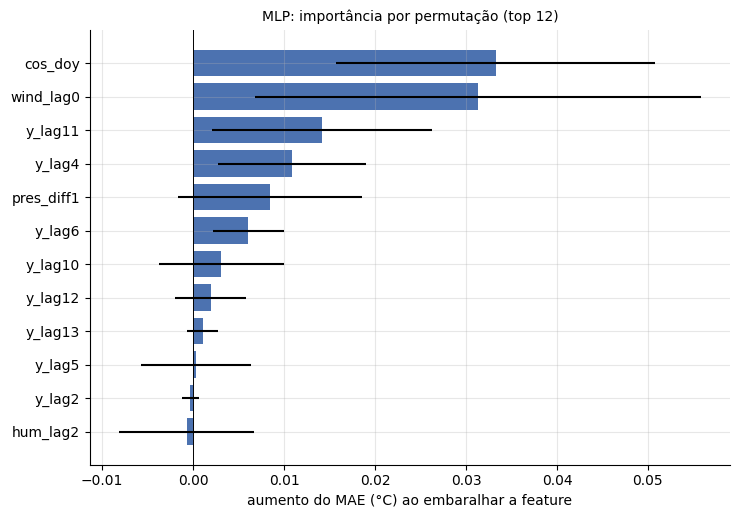

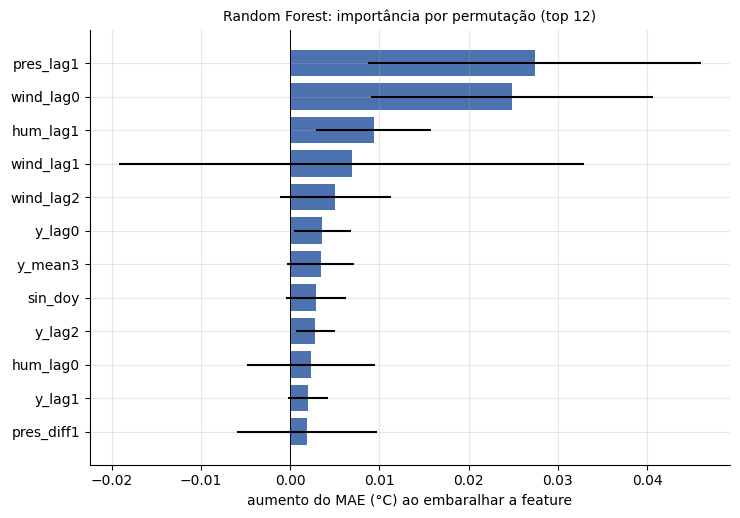

In [6]:
imp_m = pd.read_csv(R + 'importancia_mlp.csv'); imp_r = pd.read_csv(R + 'importancia_rf.csv')
gm = pd.read_csv(R + 'importancia_mlp_grupos.csv'); gr = pd.read_csv(R + 'importancia_rf_grupos.csv')
pl.importance_bars(imp_m, 'MLP: importância por permutação (top 12)', '09_importancia_mlp')
pl.importance_bars(imp_r, 'Random Forest: importância por permutação (top 12)', '10_importancia_rf')
print('Grupos de features - MLP'); display(gm.round(3))
print('Grupos de features - Random Forest'); display(gr.round(3))
print('Random Forest: permutação × impureza (MDI), top 8 por permutação'); display(imp_r.head(8).round(3))

In [7]:
cf = pd.read_csv(R + 'coeficientes_sarimax.csv')
print('SARIMAX final: ordem', sel['SARIMAX']['order'], '| AIC(CSS) = %.1f | BIC(CSS) = %.1f' % (cf.AIC_css[0], cf.BIC_css[0]))
cf['sinal'] = np.sign(cf.coef).map({1: '+', -1: '-'}); cf['significativo (5%)'] = cf.p_valor < 0.05
display(cf.drop(columns=['AIC_css', 'BIC_css']).round(3))
hws = json.load(open(R + 'estados_holt_winters.json')); print('Holt-Winters:', hws)

SARIMAX final: ordem [2, 1, 1] | AIC(CSS) = 105.6 | BIC(CSS) = 127.8
Holt-Winters: {'params': {'alpha': 0.9005317334955228, 'beta': 0.025822441322360477, 'gamma': None, 'phi': None}, 'nivel_final': 29.938316436433496, 'tendencia_final': 0.27659365159839766, 'sazonais_finais': []}


,termo,coef,erro_padrao,z,p_valor,sinal,significativo (5%)
0,humidity_lag1,0.043,0.031,1.37,0.171,+,False
1,wind_speed_lag1,-0.109,0.054,-2.009,0.045,-,True
2,meanpressure_lag1,0.038,0.108,0.352,0.725,+,False
3,sin_doy,-13.74,17.22,-0.798,0.425,-,False
4,cos_doy,-26.9,16.14,-1.666,0.096,-,False
5,ar.L1,0.334,0.573,0.583,0.56,+,False
6,ar.L2,-0.071,0.155,-0.457,0.648,-,False
7,ma.L1,-0.416,0.578,-0.719,0.472,-,False


### Interpretação (com as cautelas devidas)
**Disponibilidade temporal das exógenas.** Todas as exógenas entram **defasadas** (observadas em t ou antes), portanto **estariam disponíveis na data real da previsão**; nenhuma usa o valor futuro. O calendário do dia-alvo é conhecido antecipadamente.

**SARIMAX.** Só o coeficiente do **vento (defasado 1 dia)** é significativo a 5% (**negativo**, p ≈ 0,045). Como o modelo usa `d=1`, o regressor entra **diferenciado**: um **aumento** do vento de ontem para hoje associa-se a uma variação de temperatura menor no dia seguinte (≈ −0,11 °C por unidade de aumento), sentido plausível (advecção/mistura de ar) e coerente com a correlação −0,19 entre Δvento e Δtemperatura seguinte (notebook 01).
Umidade e pressão não são significativas; os termos sen/cos do calendário têm coeficientes grandes e erros-padrão enormes (**colinearidade**: sob d=1 eles funcionam como uma rampa) e os termos AR/MA também não são significativos, o que aponta um modelo **sobreparametrizado** para ~90 observações.
Os erros-padrão vêm da aproximação de Gauss-Newton da soma de quadrados condicional (não são os da verossimilhança exata do `statsmodels`), então os p-valores são **aproximados**.

**Random Forest.** A permutação destaca a **pressão defasada (pres_lag1)** e o **vento (wind_lag0)** como as variáveis mais úteis (aumentos de ≈ 0,03 °C no MAE), seguidas de umidade; a importância por impureza (MDI) dá peso parecido a pressão e vento, mas também a features de baixa utilidade na permutação (diferença típica entre os métodos). Por grupo: **pressão e vento** lideram; a temperatura defasada, curiosamente, **não** aparece (o alvo em Δ já embute y(t)).

**MLP.** Na permutação individual aparecem **cos_doy** (calendário), **wind_lag0** e alguns lags distantes da temperatura. Mas a importância **por grupo** do vento é **negativa** (embaralhá-lo *melhora* o MAE), o que **contradiz** o item individual `wind_lag0`: sinal de que a importância do MLP é **instável** (rede treinada uma vez, com 30 entradas correlacionadas e teste de 22 pontos).
Convergência entre modelos: o **vento (hoje)** é a única exógena que aparece útil em **RF, MLP (individual) e SARIMAX (coeficiente significativo)**, ainda que com efeito pequeno; a **pressão** é útil para RF mas não para SARIMAX.

**Síntese honesta.** As variáveis externas trazem **sinal fraco** (efeitos de centésimos de °C, de mesma ordem do ruído de permutação). O que domina a previsão de 1 dia é a **inércia** da própria temperatura.
Isso é consistente com o resultado do notebook 03 (modelos ≈ persistência) e com as correlações fracas do notebook 01.

## 10. Desempenho do MLP e possíveis explicações
- **Resultado:** MAE ≈ 1,10 °C no walk-forward (3º entre 4 modelos; ≈ +0,045 °C acima da persistência, diferença **não significativa**, DM p ≈ 0,68), resíduos sem autocorrelação detectável e sem dependência relevante da semente.
- **Por que não supera a persistência:** (1) a parte previsível da variação diária é pequena (ACF de Δy ≈ 0); (2) poucos dados para uma rede com ~13× mais parâmetros que amostras; (3) a regularização que evita o sobreajuste também aproxima o modelo da persistência;
  (4) o teste contém um choque comum de ≈ −4 °C (07/04) que nenhum modelo antecipa; (5) o aquecimento de abril leva o teste para fora da faixa do treino, e a ReLU limita a extrapolação (subestimação ≈ +0,47 °C nos dias acima do máximo do treino).
- **Comparação com a entrega original do aluno:** o MAE original informado era 6,47 °C (≈ 6× pior que a persistência), por prever o nível sem tratar o deslocamento de distribuição, usar um holdout sem walk-forward e interpretar RMSE padronizado como se fosse °C. Aqui o MAE é ≈ 1,10 °C.

## 11. Limitações e extensões
1. **Uma única base (Grupo 1)** e **114 dias** (< 1 ciclo anual): sem sazonalidade anual estimável. O código está escrito para esta base; usá-lo nas outras exige ajustar nomes de colunas e a frequência.
2. A versão pública do conjunto inclui, segundo a descrição do Kaggle, um arquivo de treino com anos anteriores. Usá-lo daria ciclos anuais completos, mas **alterar a base congelada exige aprovação prévia** (item 15 do enunciado), então não foi feito.
3. Teste com **22 pontos**: baixo poder estatístico; o ranking é instável.
4. `MLPRegressor` do `scikit-learn` (o "MLP Regressor" do enunciado) em vez de uma rede em PyTorch; não há *early stopping* próprio nem *dropout*.
5. Importâncias por permutação sobre o teste são descritivas e instáveis com features correlacionadas.
6. SARIMAX e Holt-Winters foram implementados do zero (numpy/scipy), pois o `statsmodels` não estava disponível no ambiente de execução; foram validados com séries sintéticas (`tests/`), mas **não comparados numericamente com o `statsmodels`**.